<a href="https://colab.research.google.com/github/paulinaniemczak/Machine-Learning/blob/master/Lab10-convolutional-neural-network-CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 10 - Convolutional Neural Network, CNN

### Author: Szymon Nowakowski


# Presentation on Convolutional Layers
--------------------

We shall start off by going through a [short presentation on convolusional layers](https://github.com/SzymonNowakowski/Machine-Learning-2025/blob/master/convolutional_layers.pdf). It is best to first download it and then go through it in a slide-show layout.

# Reading MNIST Dataset
----------------------------------

In [1]:
import torch
import torchvision
from matplotlib import pyplot

transform = torchvision.transforms.Compose(
    [ torchvision.transforms.ToTensor(), #Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]
      torchvision.transforms.Normalize((0.1307), (0.3081))])

trainset = torchvision.datasets.MNIST(root='./data',
                                      train=True,
                                      download=True,
                                      transform=transform)

trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=2048,
                                          shuffle=True)   #we do shuffle it to give more randomizations to training epochs

testset = torchvision.datasets.MNIST(root='./data',
                                     train=False,
                                     download=True,
                                     transform=transform)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=1,
                                         shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]


# Tensor Sizes
-------------------

Recall:
- Batched labels are of order one. The first (and only) index is a sample index within a batch.
- Image batches have order 4. The first order is a batch order, but a second order has dimensionality of 1 and thus it can be indexed by 0 only.
  - This index represents a Channel number inserted here by `ToTensor()` transformation, always 0.
  - This singleton order should be retained because we want to use convolutional layers, which explicitly require this order. For RGB images we have 3 channels, for B&W images we have only one channel.


# CNN Definition
-----------------



## Task

Your job now is to code the definition of the LeNet5 neural network. You can find the definition [here](https://en.wikipedia.org/wiki/LeNet#/media/File:Comparison_image_neural_networks.svg).


In [2]:
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(torch.nn.Module):
    def __init__(self):
        super().__init__()

        # TODO: add missing layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)

        # 16x4x4 for our data
        self.fc1 = nn.Linear(in_features=16*5*5, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=10)


        self.dropout = torch.nn.Dropout(0.05)


    def forward(self, x):
        # print("input:", x.shape)
        # TODO: add missing processing

        # convolution with sigmoid
        x = torch.sigmoid(self.conv1(x))
        # print("conv1:", x.shape)

        # pooling
        x = F.avg_pool2d(x, kernel_size=2, stride=2)
        # print("pool1:", x.shape)

        # convolution with sigmoid 2
        x = torch.sigmoid(self.conv2(x))
        # print("conv2:", x.shape)

        # pooling
        x = F.avg_pool2d(x, kernel_size=2, stride=2)
        # print("pool2:", x.shape)

        # flatten
        x = torch.flatten(x, start_dim=1)
        # print("flatten:", x.shape)

        # linear
        x = torch.sigmoid(self.fc1(x))
        # print("fc1:", x.shape)

        # linear
        x = torch.sigmoid(self.fc2(x))

        # last
        x = self.fc3(x)

        # convolution
        x = self.dropout(x)
        return x

# Training Loop
----------------------

In [3]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")

net = LeNet5().to(device)
optimizer = torch.optim.Adam(net.parameters(), 0.001)   #initial and fixed learning rate of 0.001.

net.train()    #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing traning
for epoch in range(16):  #  an epoch is a training run through the whole data set

    for batch, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        batch_inputs = batch_inputs.to(device)  #explicitly moving the data to the target device
        batch_labels = batch_labels.to(device)

        # print(batch_inputs.shape)
        # print(batch_labels.shape)

        optimizer.zero_grad()

        batch_outputs = net(batch_inputs)   #this line calls the forward(self, x) method of the LeNet5 object. Please note,
                                            # the nonlinear activation after the last layer is NOT applied
        loss = torch.nn.functional.cross_entropy(batch_outputs, batch_labels, reduction = "mean") #instead, nonlinear softmax is applied internally in THIS loss function
        print("epoch:", epoch, "batch:", batch, "current batch loss:", loss.item())
        loss.backward()       #this computes gradients as we have seen in previous workshops
        optimizer.step()     #but this line in fact updates our neural network.
                                ####You can experiment - comment this line and check, that the loss DOE

Working on cuda
epoch: 0 batch: 0 current batch loss: 2.3427138328552246
epoch: 0 batch: 1 current batch loss: 2.323452949523926
epoch: 0 batch: 2 current batch loss: 2.3142638206481934
epoch: 0 batch: 3 current batch loss: 2.308581829071045
epoch: 0 batch: 4 current batch loss: 2.299464702606201
epoch: 0 batch: 5 current batch loss: 2.308971881866455
epoch: 0 batch: 6 current batch loss: 2.2994601726531982
epoch: 0 batch: 7 current batch loss: 2.301905632019043
epoch: 0 batch: 8 current batch loss: 2.3053855895996094
epoch: 0 batch: 9 current batch loss: 2.3062872886657715
epoch: 0 batch: 10 current batch loss: 2.3066697120666504
epoch: 0 batch: 11 current batch loss: 2.3083934783935547
epoch: 0 batch: 12 current batch loss: 2.307370901107788
epoch: 0 batch: 13 current batch loss: 2.302814483642578
epoch: 0 batch: 14 current batch loss: 2.302412748336792
epoch: 0 batch: 15 current batch loss: 2.3060765266418457
epoch: 0 batch: 16 current batch loss: 2.3033056259155273
epoch: 0 batch: 

# Testing
----------------------

In [4]:
good = 0
wrong = 0

net.eval()              #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing evaluation
with torch.no_grad():   #it prevents that the net learns during evalution. The gradients are not computed, so this makes it faster, too
    for batch, data in enumerate(testloader): #batches in test are of size 1
        datapoint, label = data

        prediction = net(datapoint.to(device))                  #prediction has values representing the "prevalence" of the corresponding class
        classification = torch.argmax(prediction)    #the class is the index of maximal "prevalence"

        if classification.item() == label.item():
            good += 1
        else:
            wrong += 1

print("accuracy = ", good/(good+wrong))

accuracy =  0.9424


# Understanding Kernel Size, Stride and Padding

## Task: Designing a Convolutional Neural Network with a Target Receptive Field

Design a convolutional neural network using only 3×3 or 5×5 convolutional layers and 2×2 max-pooling layers without overlap (i.e., with stride 2). Use no padding in any layer. Insert a max-pooling layer after every two or three convolutional layers.

Your goal is to construct an architecture such that the receptive field of each output neuron is approximately 60×60 pixels.


In [5]:
import torch.nn as nn
import torch.nn.functional as F

# input size is 400x400

class field_net(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3)
    self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
    self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)
    self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5)
    self.conv5 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5)
    self.conv6 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3)
    self.conv7 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3)


    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = self.conv1(x)
    x = F.relu(x)
    x = self.conv2(x)
    x = F.relu(x)

    x = self.pool(x)

    x = self.conv3(x)
    x = F.relu(x)
    x = self.conv4(x)
    x = F.relu(x)

    x = self.pool(x)
    x = self.conv5(x)
    x = F.relu(x)
    x = self.conv6(x)
    x = F.relu(x)

    x = self.pool(x)
    x = self.conv7(x)

    return x

**Answers**

Compute the receptive field size of the final output layer.
**66**

Compute the effective stride of the output layer with respect to the input.
**8**

Assuming an input image size of 400×400, determine the spatial size of the output feature map.
**42x42x512**

Q: Where would you locate ReLU layers?
**After every convolutional layer, so the nonlinearity is introduced and the learning is improved.**

Q: What if we can't match the desired input size with our architecture?
**The architecture can be slightly modified by adding or removing convolutional layer or changing the kernel size.**

Q: Discuss what possible impact padding can have on the network performance.
**Padding preserves spatial size of output feature map and prevents border information loss, but also adds artificial information that may slightly affect feature extraction.**

# **Homework Assignment – Adversarial Examples**

In this assignment, you will explore how small (invisible to humans) changes to real digits can _fool_ the CNN into misclassifying them, even though the changes are imperceptible to humans.



## Task 1 – CNN Dreams: Last Homework Assignment Revisited

Re-run the input optimization process (for NN dreams) from the previous MLP-class homework assignment, but this time using the **LeNet-5 CNN model** we trained in this class.


1. Starting from ten random noise images, optimize the input so that each image is classified with high confidence as one of the digits 0 through 9.
2. Include an **L2 penalty** on the input to keep the images visually closer to realistic digits. Use a range of penalty strengths (e.g., $\lambda_{l2}$ = 0, and then 0.01 through 10.0).
3. Compare the generated images (with and without L2 penalty) to those generated by the MLP:
   - Are they more or less readable?
   - Do they resemble real MNIST digits more closely or less?
   - Why do you think that happens? Consider the CNN’s inductive biases and architectural properties.

Use `cross_entropy_loss + lambda_l2 * input.pow(2).mean()` as your objective.

Reuse your code: visualize confidence evolution during optimization and generate image grids and (optionally) animations showing how the inputs evolve.




iteration: 0 loss: 4.5306196212768555 mean confidence: 0.14065594971179962
iteration: 25 loss: 0.0191325843334198 mean confidence: 0.9811565279960632
iteration: 50 loss: 0.014380882494151592 mean confidence: 0.9857534766197205
iteration: 75 loss: 0.0128017608076334 mean confidence: 0.9872997403144836
iteration: 100 loss: 0.011974889785051346 mean confidence: 0.98811274766922
iteration: 125 loss: 0.011416316032409668 mean confidence: 0.9886626601219177
iteration: 150 loss: 0.011008307337760925 mean confidence: 0.989064633846283
iteration: 175 loss: 0.010694568045437336 mean confidence: 0.9893738031387329
iteration: 200 loss: 0.010443027131259441 mean confidence: 0.9896217584609985
iteration: 225 loss: 0.010235404595732689 mean confidence: 0.9898266196250916
iteration: 250 loss: 0.01006061676889658 mean confidence: 0.989998996257782
iteration: 275 loss: 0.009911454282701015 mean confidence: 0.9901461601257324


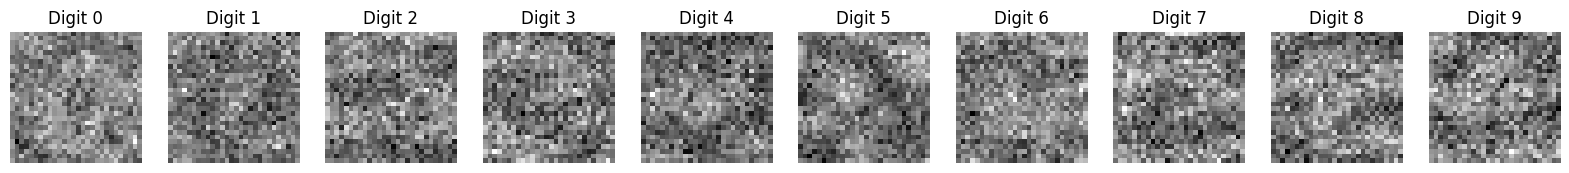

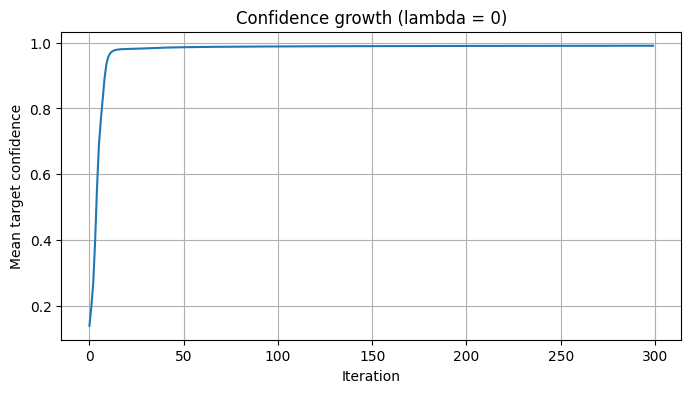

iteration: 0 loss: 5.047942161560059 mean confidence: 0.017882177606225014
iteration: 25 loss: 0.03041223995387554 mean confidence: 0.9814756512641907
iteration: 50 loss: 0.026441916823387146 mean confidence: 0.9856343269348145
iteration: 75 loss: 0.02471320331096649 mean confidence: 0.9871654510498047
iteration: 100 loss: 0.023627908900380135 mean confidence: 0.9880027770996094
iteration: 125 loss: 0.022815734148025513 mean confidence: 0.9885563254356384
iteration: 150 loss: 0.022155385464429855 mean confidence: 0.9889537692070007
iteration: 175 loss: 0.02159113623201847 mean confidence: 0.9892538189888
iteration: 200 loss: 0.021091554313898087 mean confidence: 0.9894899725914001
iteration: 225 loss: 0.02063821628689766 mean confidence: 0.9896818399429321
iteration: 250 loss: 0.020220013335347176 mean confidence: 0.989841878414154
iteration: 275 loss: 0.019829899072647095 mean confidence: 0.9899776577949524


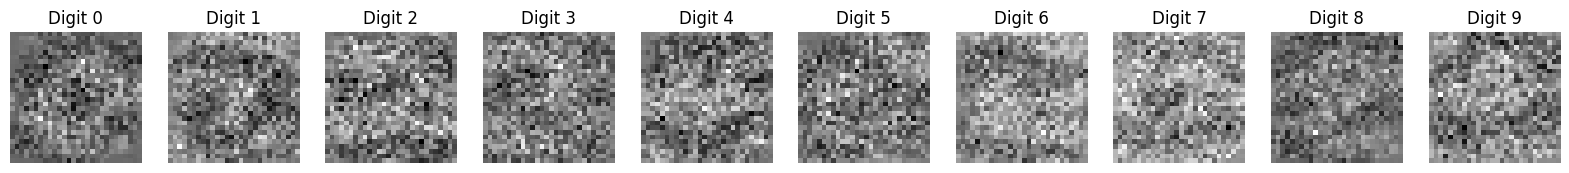

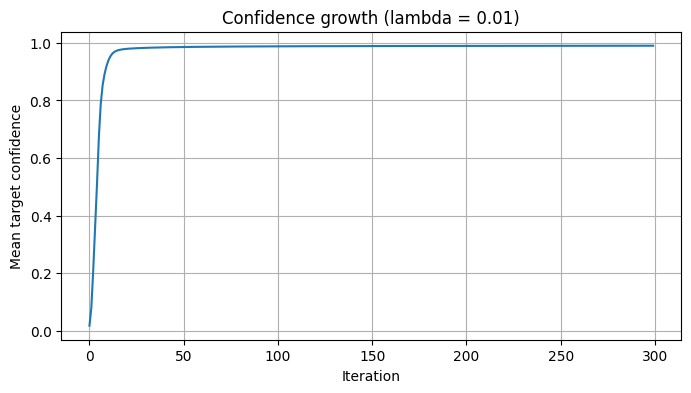

iteration: 0 loss: 3.959289312362671 mean confidence: 0.10569529980421066
iteration: 25 loss: 0.12195282429456711 mean confidence: 0.9850116968154907
iteration: 50 loss: 0.1081608459353447 mean confidence: 0.9877738356590271
iteration: 75 loss: 0.09484153240919113 mean confidence: 0.9885019659996033
iteration: 100 loss: 0.0835777148604393 mean confidence: 0.9889053702354431
iteration: 125 loss: 0.07416383922100067 mean confidence: 0.9891767501831055
iteration: 150 loss: 0.06625029444694519 mean confidence: 0.9893685579299927
iteration: 175 loss: 0.05954398214817047 mean confidence: 0.9895082712173462
iteration: 200 loss: 0.05381617695093155 mean confidence: 0.9896122217178345
iteration: 225 loss: 0.04889019578695297 mean confidence: 0.9896904230117798
iteration: 250 loss: 0.0446285679936409 mean confidence: 0.9897500872612
iteration: 275 loss: 0.04092320054769516 mean confidence: 0.9897958636283875


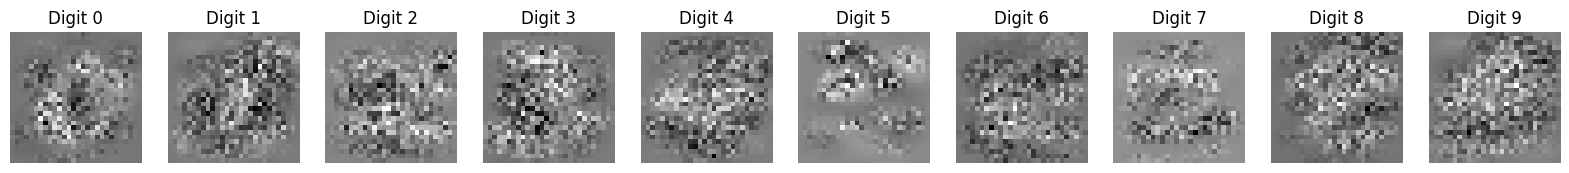

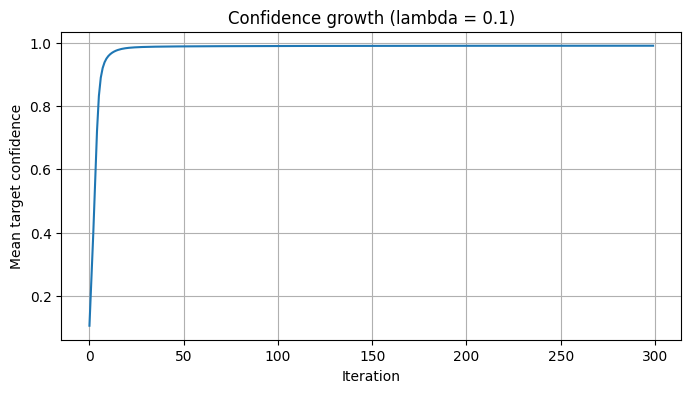

iteration: 0 loss: 4.807138442993164 mean confidence: 0.10935678333044052
iteration: 25 loss: 0.6916134357452393 mean confidence: 0.9865646362304688
iteration: 50 loss: 0.3835568428039551 mean confidence: 0.986970841884613
iteration: 75 loss: 0.22280442714691162 mean confidence: 0.9864875674247742
iteration: 100 loss: 0.13926149904727936 mean confidence: 0.9860675930976868
iteration: 125 loss: 0.09392713755369186 mean confidence: 0.9854049682617188
iteration: 150 loss: 0.06828828901052475 mean confidence: 0.9849954843521118
iteration: 175 loss: 0.053357865661382675 mean confidence: 0.9846992492675781
iteration: 200 loss: 0.04441753029823303 mean confidence: 0.9845780730247498
iteration: 225 loss: 0.03894390910863876 mean confidence: 0.9845260977745056
iteration: 250 loss: 0.03553706407546997 mean confidence: 0.9845023155212402
iteration: 275 loss: 0.033392101526260376 mean confidence: 0.9844909906387329


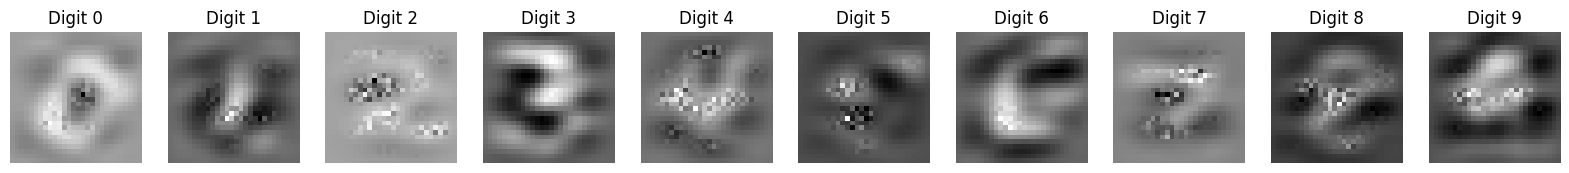

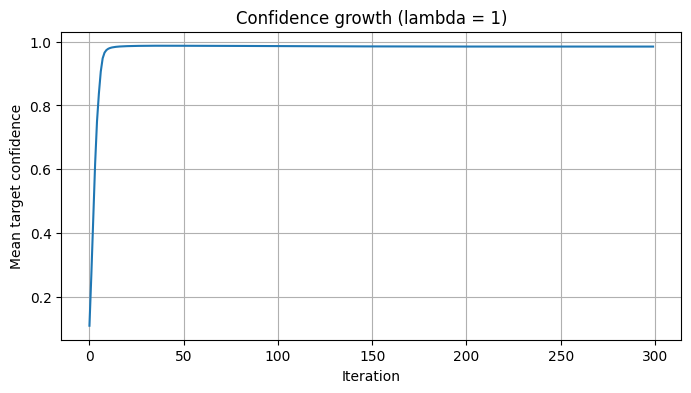

iteration: 0 loss: 13.482269287109375 mean confidence: 0.16210047900676727
iteration: 25 loss: 2.1194143295288086 mean confidence: 0.9700325131416321
iteration: 50 loss: 0.39230668544769287 mean confidence: 0.9578941464424133
iteration: 75 loss: 0.15277865529060364 mean confidence: 0.9614800810813904
iteration: 100 loss: 0.1164257824420929 mean confidence: 0.961987316608429
iteration: 125 loss: 0.11083298176527023 mean confidence: 0.961996853351593
iteration: 150 loss: 0.11001738160848618 mean confidence: 0.9620289206504822
iteration: 175 loss: 0.10990791022777557 mean confidence: 0.9620370864868164
iteration: 200 loss: 0.10989467054605484 mean confidence: 0.9620391726493835
iteration: 225 loss: 0.10989321023225784 mean confidence: 0.9620398879051208
iteration: 250 loss: 0.10989313572645187 mean confidence: 0.9620397686958313
iteration: 275 loss: 0.10989309847354889 mean confidence: 0.9620398879051208


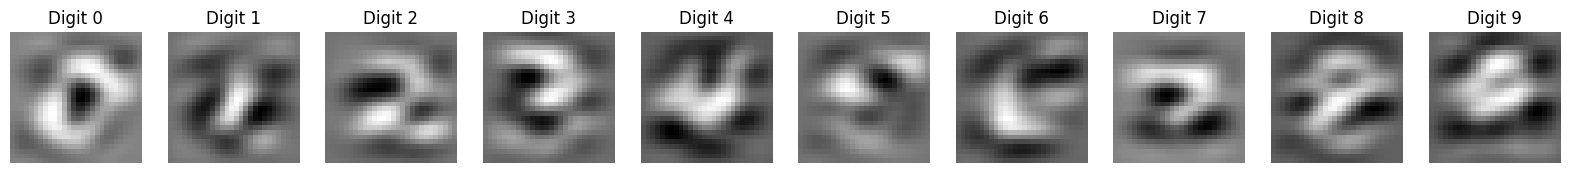

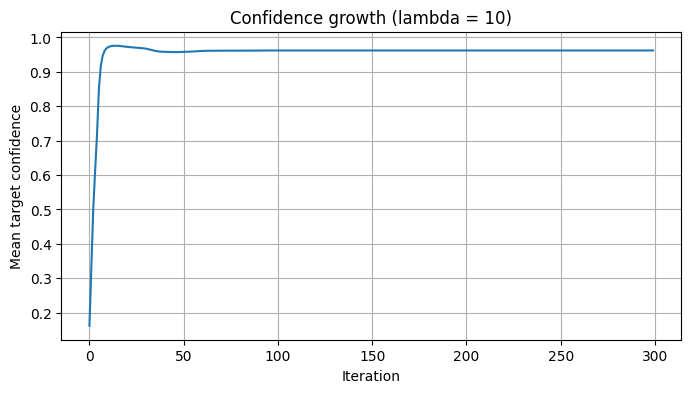

In [8]:
"""enhanced code from previous lab"""
net.eval() # LeNet-5 without training behaviors

for param in net.parameters():
  param.requires_grad = False # without weights' training

target_labels = torch.arange(10).to(device) # target labels for images from 0 to 9, tensor shape: 10


lambda_values = [0, 0.01, 0.1, 1, 10]
for lambda_l2 in lambda_values:
  dream_batch_input = torch.randn(10, 1, 28, 28, device=device) # batch of random noise images, shape: batch size, channels (grayscale, so 1), height, width
  dream_batch_input.requires_grad_(True) # gradient for input images
  dream_optimizer = torch.optim.Adam([dream_batch_input], lr=0.05) # updates input images

  iterations = 300
  confidence_history = []

  for iteration in range(iterations):
    dream_optimizer.zero_grad() # reset gradient from previous iteration

    outputs = net(dream_batch_input) # pass images

    ce_loss = F.cross_entropy(outputs, target_labels) # cross-entropy loss, digit named by their digit
    l2 = dream_batch_input.pow(2).mean()
    loss = ce_loss + lambda_l2 * l2 # total loss

    loss.backward() # gradients
    dream_optimizer.step() # update images using gradients

    probabilities = torch.softmax(outputs, dim=1)
    target_confidence = probabilities[torch.arange(10), target_labels] # confidence of given class

    confidence_history.append(target_confidence.mean().item()) # save confidence for later visualisation


    if iteration % 25 == 0:
      print(
          "iteration:", iteration,
          "loss:", loss.item(),
          "mean confidence:", target_confidence.mean().item()
      )


  # plotting
  images = dream_batch_input.detach().cpu() # moves tensor to cpu

  figure, axes = pyplot.subplots(1, 10, figsize=(20, 2))
  for i in range(10):
    image = images[i][0]
    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f"Digit {i}")
    axes[i].axis("off")
  pyplot.show()


  """ confidence growth during optimization """
  pyplot.figure(figsize=(8, 4))
  pyplot.plot(confidence_history)
  pyplot.title(f"Confidence growth (lambda = {lambda_l2})")
  pyplot.xlabel("Iteration")
  pyplot.ylabel("Mean target confidence")
  pyplot.grid()
  pyplot.show()


## Task 2 – Adversarial Examples: Fooling LeNet-5

This is the core focus of the assignment.

Using a batch of **real MNIST digits** (e.g., nine examples per class), craft **adversarial examples** by adding subtle, trained noise to the input images. Your goal is to:

- **Keep the human-perceived digit the same** (e.g., a "7" should still look like a "7"),
- But **cause LeNet-5 to misclassify it** – as every other class different from the original, hence nine examples per class.

### Objective
For each image $x$ and its true label $y$, learn a perturbation $\delta$ such that:

- $\text{LeNet5}(x + \delta) = y_{\text{wrong}} $,
- and $ \|\delta\|_2 $ is as small as possible (penalize large perturbations), to keep $x + \delta$ *look* like $x$ for humans.

### Optimization
Use gradient-based optimization on $\delta$ (the noise), while keeping the network weights frozen. Your loss might look like:

```
loss = cross_entropy(model(x + delta), target_wrong_class) +
       lambda_l2 * delta.pow(2).mean()
```

Tune the $\lambda_{l2}$ to find the best range.

### Deliverables for the Second Task
- Select some best examples, showing the original digit and its (correct) classification and the perturbed digit (hopefully, still looking the same to humans) and how it gets misclassified. Show them side by side.
- Report:
  - Success rate of attacks (it doesn't need to be very formal),
  - Effect of $\lambda_{l2}$ on visibility of the noise and success of misclassification,
  - Example image grids and confidence plots.



## Deliverables for the Homework Assignment
- A Google Colab notebook with:
  - Complete implementation for both tasks.
  - Visualizations and animations (animations are optional but encouraged).
  - Clear written analysis of your findings.
- Upload the notebook and results to your GitHub repository for the course.
- Include a link to the notebook and video (if applicable) in the `README.md`.
- In the notebook, include “Open in Colab” badge so it can be launched directly.

In [15]:
import torch
import torchvision

testset = torchvision.datasets.MNIST(root='./data',
                                      train=False,
                                      download=True,
                                      transform=transform)

image, label = testset[0]
print("image.shape:", image.shape)
print("label:", label)

# input as batch
image = image.unsqueeze(0).to(device)
print("image.shape:", image.shape)

# prediction = net(image + delta)

""""""
net.eval() # LeNet-5 without training behaviors

for param in net.parameters():
  param.requires_grad = False # without weights' training

target_wrong_class = torch.tensor([1]).to(device)


lambda_values = [0, 0.01, 0.1, 1, 10]
for lambda_l2 in lambda_values:
  print("lambda=", lambda_l2)

  # delta
  delta = torch.zeros_like(image, requires_grad=True)
  print("delta.shape:", delta.shape)

  dream_optimizer = torch.optim.Adam([delta], lr=0.05) # updates input images

  iterations = 300
  confidence_history = []

  for iteration in range(iterations):
    dream_optimizer.zero_grad() # reset gradient from previous iteration

    outputs = net(image + delta) # pass images

    ce_loss = F.cross_entropy(outputs, target_wrong_class) # cross-entropy loss, digit named by their digit
    l2 = delta.pow(2).mean()

    loss = ce_loss + lambda_l2 * l2 # total loss

    loss.backward() # gradients
    dream_optimizer.step() # update images using gradients

    probabilities = torch.softmax(outputs, dim=1)
    target_confidence = probabilities[0, target_wrong_class.item()] # confidence of given class


    confidence_history.append(target_confidence.item()) # save confidence for later visualisation


    if iteration % 25 == 0:
      print(
          "iteration:", iteration,
          "loss:", loss.item(),
          "mean confidence:", target_confidence.mean().item()
      )
# prediction
with torch.no_grad():
  original_prediction = net(image).argmax(dim=1).item()
  adversarial_prediction = net(image + delta).argmax(dim=1).item()


# plotting
images = (image + delta).detach().cpu() # moves tensor to cpu

figure, axes = pyplot.subplots(1, 2, figsize=(6, 3))
# for i in range(10):
  # image = images[i][0]
  # axes[i].imshow(image, cmap="gray")
  # axes[i].set_title(f"Digit {i}")
  # axes[i].axis("off")

axes[0].imshow(image.cpu()[0, 0], cmap="gray")
axes[0].set_title(
    f"Original\nTrue={label}\nPred={original_prediction}"
)

axes[1].imshow((image + delta).detach().cpu()[0, 0], cmap="gray")
axes[1].set_title(
    f"Attack\nTarget={target_wrong_class.item()}\nPred={adversarial_prediction}"
)

for ax in axes:
    ax.axis("off")

pyplot.show()


""" confidence growth during optimization """
pyplot.figure(figsize=(8, 4))
pyplot.plot(confidence_history)
pyplot.title(f"Confidence growth (lambda = {lambda_l2})")
pyplot.xlabel("Iteration")
pyplot.ylabel("Mean target confidence")
pyplot.grid()
pyplot.show()

print(target_wrong_class)
print(outputs.shape)




image.shape: torch.Size([1, 28, 28])
label: 7


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
